<a href="https://colab.research.google.com/github/syauqidamario/thesis-MTI-syauqi/blob/main/03_development_and_train_model.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import MinMaxScaler

In [ ]:
# baca data
df_price = pd.read_csv('bbca_historical_price_5years.csv') # Dari Yahoo Finance
df_sentiment = pd.read_csv('02_dataset_siap_training.csv') # Hasil Notebook 02
df_macro = pd.read_csv('ekonomi_makro_indonesia.csv') # BI Rate, Inflasi, Kurs

In [ ]:
print("Kolom Price:", df_price.columns.tolist())
print("Kolom Sentiment:", df_sentiment.columns.tolist())
print("Kolom Macro:", df_macro.columns.tolist())

Kolom Price: ['Price', 'Close', 'High', 'Low', 'Open', 'Volume']
Kolom Sentiment: ['date', 'aggregated_news', 'news_count', 'sentiment_score']
Kolom Macro: ['Date', 'Kurs']


In [ ]:
# Kita seragamkan dulu nama kolomnya ke 'Date' (D-nya besar)
df_price.rename(columns={'date': 'Date'}, inplace=True, errors='ignore')
df_sentiment.rename(columns={'date': 'Date'}, inplace=True, errors='ignore')
df_macro.rename(columns={'date': 'Date'}, inplace=True, errors='ignore')

In [ ]:
# Fungsi sakti untuk mencari dan menyeragamkan kolom tanggal
def fix_date_column(df, name):
    # Ubah semua nama kolom jadi lowercase untuk pengecekan
    df.columns = [c.strip() for c in df.columns] # Hapus spasi di awal/akhir nama kolom

    # Cari kolom yang mengandung kata 'date' (tidak peduli besar kecil hurufnya)
    date_col = [c for c in df.columns if 'date' in c.lower()]

    if date_col:
        # Rename kolom tersebut menjadi 'Date' agar konsisten
        df.rename(columns={date_col[0]: 'Date'}, inplace=True)
        print(f"Berhasil menemukan kolom tanggal di {name}: '{date_col[0]}' -> 'Date'")
    else:
        print(f"PERINGATAN: Kolom tanggal TIDAK ditemukan di {name}!")
    return df

In [ ]:
# Terapkan fungsi ke semua DataFrame
df_price = fix_date_column(df_price, "Price Data")
df_sentiment = fix_date_column(df_sentiment, "Sentiment Data")
df_macro = fix_date_column(df_macro, "Macro Data")

PERINGATAN: Kolom tanggal TIDAK ditemukan di Price Data!
Berhasil menemukan kolom tanggal di Sentiment Data: 'Date' -> 'Date'
Berhasil menemukan kolom tanggal di Macro Data: 'Date' -> 'Date'


In [ ]:
# Ini akan mengatasi masalah jika 'Date' terjebak di Index
df_price = df_price.reset_index()
df_sentiment = df_sentiment.reset_index()
df_macro = df_macro.reset_index()

In [ ]:
# Bersihkan nama kolom dari spasi dan seragamkan ke 'Date'
for df in [df_price, df_sentiment, df_macro]:
    df.columns = [str(c).strip() for c in df.columns] # Hapus spasi
    # Cari kolom mana saja yang namanya mirip 'date'
    date_cols = [c for c in df.columns if 'date' in c.lower()]
    if date_cols:
        df.rename(columns={date_cols[0]: 'Date'}, inplace=True)

In [ ]:
# Investigasi Struktur Dataset
for name, df in [("Price", df_price), ("Sentiment", df_sentiment), ("Macro", df_macro)]:
    print(f"\n--- Memeriksa {name} Data ---")
    print(f"Daftar Kolom Asli: {df.columns.tolist()}")

    # Deteksi kolom yang mengandung kata 'date'
    found_cols = [c for c in df.columns if 'date' in str(c).lower()]
    print(f"Kolom yang mirip 'date': {found_cols}")

    if 'Date' in df.columns:
        print("STATUS: OK (Kolom 'Date' ditemukan)")
    else:
        print("STATUS: ERROR (Kolom 'Date' TIDAK ditemukan)")

        # Coba perbaiki secara paksa hanya untuk DF yang error ini
        if found_cols:
            df.rename(columns={found_cols[0]: 'Date'}, inplace=True)
            print(f"TINDAKAN: Mengubah '{found_cols[0]}' menjadi 'Date'")
        else:
            print("TINDAKAN: GAGAL (Tidak ada kolom yang mirip 'date')")

# Setelah investigasi selesai, coba konversi satu per satu untuk tahu mana yang bikin macet
try:
    df_price['Date'] = pd.to_datetime(df_price['Date']).dt.date
    print("Price: Sukses")
    df_sentiment['Date'] = pd.to_datetime(df_sentiment['Date']).dt.date
    print("Sentiment: Sukses")
    df_macro['Date'] = pd.to_datetime(df_macro['Date']).dt.date
    print("Macro: Sukses")
except Exception as e:
    print(f"\nSTOP! Error terjadi lagi: {e}")


--- Memeriksa Price Data ---
Daftar Kolom Asli: ['index', 'Price', 'Close', 'High', 'Low', 'Open', 'Volume']
Kolom yang mirip 'date': []
STATUS: ERROR (Kolom 'Date' TIDAK ditemukan)
TINDAKAN: GAGAL (Tidak ada kolom yang mirip 'date')

--- Memeriksa Sentiment Data ---
Daftar Kolom Asli: ['index', 'Date', 'aggregated_news', 'news_count', 'sentiment_score']
Kolom yang mirip 'date': ['Date']
STATUS: OK (Kolom 'Date' ditemukan)

--- Memeriksa Macro Data ---
Daftar Kolom Asli: ['index', 'Date', 'Kurs']
Kolom yang mirip 'date': ['Date']
STATUS: OK (Kolom 'Date' ditemukan)

STOP! Error terjadi lagi: 'Date'


In [ ]:
if 'index' in df_price.columns and 'Date' not in df_price.columns:
    df_price.rename(columns={'index': 'Date'}, inplace=True)
    print("Berhasil! Kolom 'index' pada df_price telah diubah menjadi 'Date'.")

# 2. Sekarang jalankan konversi tipe datanya (SEKARANG PASTI BISA)
df_price['Date'] = pd.to_datetime(df_price['Date']).dt.date
df_sentiment['Date'] = pd.to_datetime(df_sentiment['Date']).dt.date
df_macro['Date'] = pd.to_datetime(df_macro['Date']).dt.date

print("Semua data berhasil dikonversi ke format Date!")

Berhasil! Kolom 'index' pada df_price telah diubah menjadi 'Date'.
Semua data berhasil dikonversi ke format Date!


In [ ]:
# Gabungkan semuanya (Merging)
df_merged = pd.merge(df_price, df_sentiment[['Date', 'sentiment_score', 'news_count']], on='Date', how='left')
df_merged = pd.merge(df_merged, df_macro, on='Date', how='left')
print(df_merged.head())

         Date       Price        Close               High                Low  \
0  1970-01-01      Ticker      BBCA.JK            BBCA.JK            BBCA.JK   
1  1970-01-01        Date          NaN                NaN                NaN   
2  1970-01-01  2020-01-02  5540.171875  5614.703335201793  5531.890601644245   
3  1970-01-01  2020-01-03  5631.265625        5631.265625  5569.156077665441   
4  1970-01-01  2020-01-06    5577.4375  5589.859409799555  5540.171770601337   

                Open    Volume  sentiment_score  news_count  index  Kurs  
0            BBCA.JK   BBCA.JK              NaN         NaN    NaN   NaN  
1                NaN       NaN              NaN         NaN    NaN   NaN  
2  5544.312511677877  49445000              NaN         NaN    NaN   NaN  
3  5589.859260110294  47755500              NaN         NaN    NaN   NaN  
4  5565.015590200445  27300000              NaN         NaN    NaN   NaN  


In [ ]:
# 1. Buang 2 baris pertama yang isinya metadata (Ticker, BBCA.JK, dll)
# Kita ambil data mulai dari baris yang isinya tanggal asli (baris ke-2 ke bawah)
df_price_clean = df_price.iloc[2:].copy()

# 2. Perbaiki nama kolom secara manual agar bersih
# Berdasarkan gambar, kolom kedua kamu (indeks 1) isinya adalah tanggal yang benar
df_price_clean.columns = ['Trash', 'Date', 'Close', 'High', 'Low', 'Open', 'Volume']
df_price_clean = df_price_clean[['Date', 'Open', 'High', 'Low', 'Close', 'Volume']]

# 3. Konversi ulang ke datetime (sekarang isinya sudah angka tanggal asli)
df_price_clean['Date'] = pd.to_datetime(df_price_clean['Date']).dt.date

# 4. Pastikan kolom angka adalah tipe numeric (karena tadi sempat terbaca string)
for col in ['Open', 'High', 'Low', 'Close', 'Volume']:
    df_price_clean[col] = pd.to_numeric(df_price_clean[col], errors='coerce')

# 5. Cek hasilnya
print("Data Price yang sudah bersih:")
print(df_price_clean.head())

# Sekarang jalankan merging ulang dengan df_price_clean
df_merged = pd.merge(df_price_clean, df_sentiment[['Date', 'sentiment_score', 'news_count']], on='Date', how='left')
df_merged = pd.merge(df_merged, df_macro[['Date', 'Kurs']], on='Date', how='left')

print("\nData Gabungan Berhasil:")
print(df_merged.head())

Data Price yang sudah bersih:
         Date         Open         High          Low        Close    Volume
2  2020-01-02  5544.312512  5614.703335  5531.890602  5540.171875  49445000
3  2020-01-03  5589.859260  5631.265625  5569.156078  5631.265625  47755500
4  2020-01-06  5565.015590  5589.859410  5540.171771  5577.437500  27300000
5  2020-01-07  5577.437488  5606.421945  5573.296852  5581.578125  45022500
6  2020-01-08  5523.608864  5585.718409  5523.608864  5531.890137  53692500

Data Gabungan Berhasil:
         Date         Open         High          Low        Close    Volume  \
0  2020-01-02  5544.312512  5614.703335  5531.890602  5540.171875  49445000   
1  2020-01-03  5589.859260  5631.265625  5569.156078  5631.265625  47755500   
2  2020-01-06  5565.015590  5589.859410  5540.171771  5577.437500  27300000   
3  2020-01-07  5577.437488  5606.421945  5573.296852  5581.578125  45022500   
4  2020-01-08  5523.608864  5585.718409  5523.608864  5531.890137  53692500   

   sentiment_s

In [ ]:
# Pembersihan struktur data price
# 1. Kita ambil data mulai dari baris ke-2 (karena baris 0 & 1 itu sampah/metadata)
df_price_fixed = df_price.iloc[2:].copy()

# 2. Sekarang kita beri nama kolom yang benar secara manual
# Berdasarkan screenshotmu, kolom kedua (indeks 1) adalah tanggal yang asli
df_price_fixed.columns = ['Trash', 'Date', 'Close', 'High', 'Low', 'Open', 'Volume']

# 3. Buang kolom 'Trash' yang isinya tahun 1970 tadi
df_price_fixed = df_price_fixed[['Date', 'Open', 'High', 'Low', 'Close', 'Volume']]

# 4. Konversi kolom Date yang baru ke format datetime yang benar
df_price_fixed['Date'] = pd.to_datetime(df_price_fixed['Date']).dt.date

# 5. Pastikan angka harga bukan berupa tulisan (string), tapi angka (float)
cols_numeric = ['Open', 'High', 'Low', 'Close', 'Volume']
for col in cols_numeric:
    df_price_fixed[col] = pd.to_numeric(df_price_fixed[col], errors='coerce')

# 6. Cek hasilnya, sekarang harusnya sudah tahun 2020
print("Hasil perbaikan df_price:")
print(df_price_fixed.head())

# 7. Jalankan Merging ulang dengan data yang sudah SEHAT
df_merged = pd.merge(df_price_fixed, df_sentiment[['Date', 'sentiment_score', 'news_count']], on='Date', how='left')
df_merged = pd.merge(df_merged, df_macro[['Date', 'Kurs']], on='Date', how='left')

print("\nData Terintegrasi Final:")
print(df_merged.head())

Hasil perbaikan df_price:
         Date         Open         High          Low        Close    Volume
2  2020-01-02  5544.312512  5614.703335  5531.890602  5540.171875  49445000
3  2020-01-03  5589.859260  5631.265625  5569.156078  5631.265625  47755500
4  2020-01-06  5565.015590  5589.859410  5540.171771  5577.437500  27300000
5  2020-01-07  5577.437488  5606.421945  5573.296852  5581.578125  45022500
6  2020-01-08  5523.608864  5585.718409  5523.608864  5531.890137  53692500

Data Terintegrasi Final:
         Date         Open         High          Low        Close    Volume  \
0  2020-01-02  5544.312512  5614.703335  5531.890602  5540.171875  49445000   
1  2020-01-03  5589.859260  5631.265625  5569.156078  5631.265625  47755500   
2  2020-01-06  5565.015590  5589.859410  5540.171771  5577.437500  27300000   
3  2020-01-07  5577.437488  5606.421945  5573.296852  5581.578125  45022500   
4  2020-01-08  5523.608864  5585.718409  5523.608864  5531.890137  53692500   

   sentiment_scor

In [ ]:
# Handling Missing Values (Imputasi)
# Sentimen: Jika NaN, berarti tidak ada berita = Netral (0)
df_merged['sentiment_score'] = df_merged['sentiment_score'].fillna(0)
df_merged['news_count'] = df_merged['news_count'].fillna(0)

In [ ]:
# Kurs: Jika ada NaN, ambil nilai dari hari sebelumnya (Forward Fill)
df_merged['Kurs'] = df_merged['Kurs'].fillna(method='ffill')

/tmp/ipykernel_1970/2984895160.py:2: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df_merged['Kurs'] = df_merged['Kurs'].fillna(method='ffill')


**FEATURE ENGINEERING - INDIKATOR TEKNIKAL**

In [ ]:
# tambahkan MA20 dan RSI sesuai rencana di Bab III
df_merged['MA20'] = df_merged['Close'].rolling(window=20).mean()
df_merged['RSI'] = 100 - (100 / (1 + df_merged['Close'].pct_change().rolling(window=14).mean()))

In [ ]:
# Hapus baris NaN hasil rolling window di atas
df_merged.dropna(inplace=True)

Normalisasi Data

In [ ]:
# fitur yang akan masuk model
features_to_scale = ['Open', 'High', 'Low', 'Close', 'Volume', 'sentiment_score', 'news_count', 'Kurs', 'MA20', 'RSI']

In [ ]:
scaler = MinMaxScaler(feature_range=(0, 1))
df_merged[features_to_scale] = scaler.fit_transform(df_merged[features_to_scale])

In [ ]:
df_merged.to_csv('03_final_dataset_ready.csv', index=False)
print(df_merged.head())

          Date      Open      High       Low     Close    Volume  \
19  2020-01-29  0.307466  0.270042  0.320469  0.305107  0.057931   
20  2020-01-30  0.313354  0.270042  0.315226  0.299277  0.095171   
21  2020-01-31  0.307466  0.264537  0.282459  0.265592  0.215666   
22  2020-02-03  0.265598  0.234257  0.268041  0.260410  0.198031   
23  2020-02-04  0.277374  0.239074  0.287702  0.281139  0.149804   

    sentiment_score  news_count      Kurs      MA20       RSI  
19              1.0         0.0  0.037526  0.253913  0.616684  
20              1.0         0.0  0.031899  0.254289  0.609158  
21              1.0         0.0  0.040112  0.251878  0.537956  
22              1.0         0.0  0.037281  0.249654  0.495419  
23              1.0         0.0  0.066109  0.248599  0.546949  


**WINDOWING & DATA SPLITTING**

In [ ]:
def create_sequences(data, target, window_size):
    X = []
    y = []
    for i in range(len(data) - window_size):
        # Ambil data dari hari ke-i sampai hari ke-i+window_size
        X.append(data[i:(i + window_size)])
        # Target adalah harga 'Close' pada hari ke i+window_size
        y.append(target[i + window_size])
    return np.array(X), np.array(y)

In [ ]:
# Menentukan fitur dan target
feature_cols = ['Open', 'High', 'Low', 'Close', 'Volume', 'sentiment_score', 'news_count', 'Kurs', 'MA20', 'RSI']
X_data = df_merged[feature_cols].values
y_data = df_merged['Close'].values # Target prediksi adalah harga penutupan

In [ ]:
# 2. Tentukan Window Size (Misal: 30 hari untuk prediksi hari ke-31)
WINDOW_SIZE = 30
X_seq, y_seq = create_sequences(X_data, y_data, WINDOW_SIZE)

In [ ]:
# Train test split
# Pembagian 80-10-10 sesuai rencana di Bab III naskahmu
train_size = int(len(X_seq) * 0.8)
val_size = int(len(X_seq) * 0.1)
X_train, y_train = X_seq[:train_size], y_seq[:train_size]
X_val, y_val = X_seq[train_size:train_size+val_size], y_seq[train_size:train_size+val_size]
X_test, y_test = X_seq[train_size+val_size:], y_seq[train_size+val_size:]
print(f"Shape X_train: {X_train.shape}")

Shape X_train: (1118, 30, 10)


Callback Function

In [ ]:
import os
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau

def get_callbacks(model_name):
    """
    Fungsi modular untuk menghasilkan daftar callbacks bagi setiap model.
    """
    # Membuat folder untuk menyimpan model jika belum ada
    if not os.path.exists('models'):
        os.makedirs('models')

    callbacks = [
        # 1. EarlyStopping: Berhenti jika val_loss tidak membaik selama 10 epoch
        EarlyStopping(
            monitor='val_loss',
            patience=10,
            restore_best_weights=True,
            verbose=1
        ),

        # 2. ModelCheckpoint: Simpan bobot terbaik di folder 'models/'
        ModelCheckpoint(
            filepath=f'models/best_{model_name}.h5',
            monitor='val_loss',
            save_best_only=True,
            verbose=1
        ),

        # 3. ReduceLROnPlateau: Menurunkan learning rate jika training stagnan
        # Ini sangat membantu agar model tidak 'terjebak' di local minima
        ReduceLROnPlateau(
            monitor='val_loss',
            factor=0.2,
            patience=5,
            min_lr=0.00001,
            verbose=1
        )
    ]
    return callbacks

**Model CNN**

In [ ]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv1D, MaxPooling1D, Flatten, Dense, Dropout, BatchNormalization

In [ ]:
def build_cnn(input_shape):
    model = Sequential([
        Conv1D(filters=64, kernel_size=3, activation='relu', input_shape=input_shape),
        # pakai 64 filter dengan ukuran kernel 3
        BatchNormalization(),
        # stabilisasi proses training
        MaxPooling1D(pool_size=2),
        # mengambil fitur paling meonjol
        Flatten(),
        Dense(50, activation='relu'),
        Dropout(0.2),
        # Flatten, Dense mengubah matriks jadi vektor untuk prediksi
        # Dropout mencegah overfitting
        Dense (1)
    ])

    model.compile(optimizer='adam', loss='mse', metrics=['mae'])
    return model

# Cek struktur model
input_dim = (X_train.shape[1], X_train.shape[2])
cnn_model = build_cnn(input_dim)
cnn_model.summary()

# Conv1D karena di sini model mulai bealjar melihat "bentuk" grafik selama 3 hari berturut-turut
# BatchNormalization agar model tidak "kaget" saat ada lonjakan data makro atau sentimen yang ekstrem

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d (Conv1D)                 │ (None, 28, 64)         │         1,984 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 28, 64)         │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d (MaxPooling1D)    │ (None, 14, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 896)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 50)             │        44,850 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 50)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            51 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 47,141 (184.14 KB)

 Trainable params: 47,013 (183.64 KB)

 Non-trainable params: 128 (512.00 B)

Callback function itu dipasang di semua model untuk mencegah overfitting dan agar efisien.

EarlyStopping dan ModelCheckpoint akan di pasang di bagian ini untuk menghentikan proses training dan menyimpan model terbaik secara otomatis

**LSTM Architecture**

In [ ]:
from tensorflow.keras.layers import LSTM
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint

def build_lstm(input_shape):
    model = Sequential([
        LSTM(units=100, return_sequences=False, input_shape=input_shape),
        Dropout(0.2),
        Dense(32, activation='relu'),
        Dense(1)
    ])

    model.compile(optimizer='adam', loss='mse', metrics=['mae'])
    return model

# Early Stopping untuk menghentikan loss validasi jika tidak turun dalam 10 epoch
# ModelCheckpoint untuk menyimpan model terbaik
# LSTM Layer untuk menangkap ketergantungan temporal jangka panjang
# return_sequences=False karena hanya butuh 1 output di akhir
# Dropout untuk mencegah overfitting sesuai metodologi

# Inisialisasi model
lstm_model = build_lstm(input_dim)
lstm_model.summary()

#LSTM Units(100) karena ini kapasitas memori model untuk mengingat tren harga saham dan pola sentimen selama 30 hari

/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 100)            │        44,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 100)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 32)             │         3,232 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 47,665 (186.19 KB)

 Trainable params: 47,665 (186.19 KB)

 Non-trainable params: 0 (0.00 B)

**Model Hybrid CNN-LSTM**

In [ ]:
from tensorflow.keras.layers import TimeDistributed

In [ ]:
def build_hybrid_model(input_shape):
    model = Sequential([
        #Blok CNN - ekstraksi fitur spasial
        #Conv1D untuk memindai pola lokal dalam window 30 hari
        Conv1D(filters=64, kernel_size=3, activation='relu', input_shape=input_shape),
        BatchNormalization(),
        MaxPooling1D(pool_size=2),

        #Blok LSTM - ekstraksi fitur temporal
        #LSTM untuk memindai pola temporal dalam window 30 hari
        LSTM(units=100, return_sequences=False),
        Dropout(0.2),

        #Fully Connected layer
        Dense(32, activation='relu'),

        #Output Layer
        Dense(1)
    ])

    model.compile(optimizer='adam', loss='mse', metrics=['mae'])
    return model

#Inisialisasi model hybrid
hybrid_model = build_hybrid_model(input_dim)
hybrid_model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d_1 (Conv1D)               │ (None, 28, 64)         │         1,984 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 28, 64)         │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_1 (MaxPooling1D)  │ (None, 14, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 100)            │        66,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 100)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 32)             │         3,232 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 71,505 (279.32 KB)

 Trainable params: 71,377 (278.82 KB)

 Non-trainable params: 128 (512.00 B)

**Training**

In [ ]:
architectures = {
    'CNN': cnn_model,
    'LSTM': lstm_model,
    'Hybrid': hybrid_model
}

In [ ]:
epoch_targets = [100, 150, 200]
all_histories = {}

In [ ]:
for name, model in architectures.items():
    for target in epoch_targets:
        experiment_id = f"{name}_{target}eps"
        print(f"\n>>> Running Experiment: {experiment_id}")

        # Reset weights agar training mulai dari nol setiap kali ganti target epoch
        # Ini penting agar hasil 150 epoch bukan 'sambungan' dari 100 epoch
        model.set_weights(model.get_weights())

        history = model.fit(
            X_train, y_train,
            validation_data=(X_val, y_val),
            epochs=target,
            batch_size=32,
            callbacks=get_callbacks(experiment_id), # Nama file model jadi unik
            verbose=0 # Matikan log panjang agar notebook tetap bersih
        )

        all_histories[experiment_id] = history
        # print(f"Training complete for {experiment_id}")
        # print(f"Train MAE: {history.history['mae'][-1]}")


>>> Running Experiment: CNN_100eps

Epoch 1: val_loss improved from None to 0.00566, saving model to models/best_CNN_100eps.h5



Epoch 1: finished saving model to models/best_CNN_100eps.h5

Epoch 2: val_loss did not improve from 0.00566

Epoch 3: val_loss did not improve from 0.00566

Epoch 4: val_loss did not improve from 0.00566

Epoch 5: val_loss did not improve from 0.00566

Epoch 6: val_loss did not improve from 0.00566

Epoch 6: ReduceLROnPlateau reducing learning rate to 1e-05.

Epoch 7: val_loss did not improve from 0.00566

Epoch 8: val_loss did not improve from 0.00566

Epoch 9: val_loss did not improve from 0.00566

Epoch 10: val_loss did not improve from 0.00566

Epoch 11: val_loss did not improve from 0.00566
Epoch 11: early stopping
Restoring model weights from the end of the best epoch: 1.

>>> Running Experiment: CNN_150eps

Epoch 1: val_loss improved from None to 0.00579, saving model to models/best_CNN_150eps.h5



Epoch 1: finished saving model to models/best_CNN_150eps.h5

Epoch 2: val_loss did not improve from 0.00579

Epoch 3: val_loss did not improve from 0.00579

Epoch 4: val_loss did not improve from 0.00579

Epoch 5: val_loss did not improve from 0.00579

Epoch 6: val_loss did not improve from 0.00579

Epoch 7: val_loss did not improve from 0.00579

Epoch 8: val_loss did not improve from 0.00579

Epoch 9: val_loss did not improve from 0.00579

Epoch 10: val_loss did not improve from 0.00579

Epoch 11: val_loss did not improve from 0.00579
Epoch 11: early stopping
Restoring model weights from the end of the best epoch: 1.

>>> Running Experiment: CNN_200eps

Epoch 1: val_loss improved from None to 0.00595, saving model to models/best_CNN_200eps.h5



Epoch 1: finished saving model to models/best_CNN_200eps.h5

Epoch 2: val_loss did not improve from 0.00595

Epoch 3: val_loss did not improve from 0.00595

Epoch 4: val_loss did not improve from 0.00595

Epoch 5: val_loss did not improve from 0.00595

Epoch 6: val_loss did not improve from 0.00595

Epoch 7: val_loss did not improve from 0.00595

Epoch 8: val_loss did not improve from 0.00595

Epoch 9: val_loss did not improve from 0.00595

Epoch 10: val_loss did not improve from 0.00595

Epoch 11: val_loss did not improve from 0.00595
Epoch 11: early stopping
Restoring model weights from the end of the best epoch: 1.

>>> Running Experiment: LSTM_100eps

Epoch 1: val_loss improved from None to 0.00094, saving model to models/best_LSTM_100eps.h5



Epoch 1: finished saving model to models/best_LSTM_100eps.h5

Epoch 2: val_loss did not improve from 0.00094

Epoch 3: val_loss improved from 0.00094 to 0.00093, saving model to models/best_LSTM_100eps.h5


...


Epoch 1: finished saving model to models/best_Hybrid_150eps.h5

Epoch 2: val_loss did not improve from 0.00159

Epoch 3: val_loss did not improve from 0.00159

Epoch 4: val_loss did not improve from 0.00159

Epoch 5: val_loss improved from 0.00159 to 0.00158, saving model to models/best_Hybrid_150eps.h5



Epoch 5: finished saving model to models/best_Hybrid_150eps.h5

Epoch 6: val_loss did not improve from 0.00158

Epoch 7: val_loss did not improve from 0.00158

Epoch 8: val_loss did not improve from 0.00158

Epoch 9: val_loss did not improve from 0.00158

Epoch 10: val_loss did not improve from 0.00158

Epoch 11: val_loss did not improve from 0.00158

Epoch 12: val_loss improved from 0.00158 to 0.00158, saving model to models/best_Hybrid_150eps.h5



Epoch 12: finished saving model to models/best_Hybrid_150eps.h5

Epoch 13: val_loss did not improve from 0.00158

Epoch 14: val_loss did not improve from 0.00158

Epoch 15: val_loss did not improve from 0.00158

Epoch 16: val_loss did not improve from 0.00158

Epoch 17: val_loss did not improve from 0.00158

Epoch 18: val_loss did not improve from 0.00158

Epoch 19: val_loss did not improve from 0.00158

Epoch 20: val_loss did not improve from 0.00158

Epoch 21: val_loss did not improve from 0.00158

Epoch 22: val_loss did not improve from 0.00158
Epoch 22: early stopping
Restoring model weights from the end of the best epoch: 12.

>>> Running Experiment: Hybrid_200eps

Epoch 1: val_loss improved from None to 0.00158, saving model to models/best_Hybrid_200eps.h5



Epoch 1: finished saving model to models/best_Hybrid_200eps.h5

Epoch 2: val_loss improved from 0.00158 to 0.00157, saving model to models/best_Hybrid_200eps.h5



Epoch 2: finished saving model to models/best_Hybrid_200eps.h5

Epoch 3: val_loss did not improve from 0.00157

Epoch 4: val_loss did not improve from 0.00157

Epoch 5: val_loss did not improve from 0.00157

Epoch 6: val_loss did not improve from 0.00157

Epoch 7: val_loss did not improve from 0.00157

Epoch 8: val_loss did not improve from 0.00157

Epoch 9: val_loss did not improve from 0.00157

Epoch 10: val_loss did not improve from 0.00157

Epoch 11: val_loss did not improve from 0.00157

Epoch 12: val_loss did not improve from 0.00157
Epoch 12: early stopping
Restoring model weights from the end of the best epoch: 2.


**Results Processing**

1. Load Model Terbaik

In [ ]:
import tensorflow as tf
from tensorflow.keras.models import load_model
from tensorflow.keras.metrics import MeanSquaredError as KerasMSEMetric

best_model_path = 'models/best_Hybrid_200eps.h5'

# Provide the MeanSquaredError metric class as a custom object
# named 'mse' to resolve the deserialization error.
custom_objects = {
    'mse': KerasMSEMetric # This maps the string 'mse' to the actual metric class
}

best_model = load_model(best_model_path, custom_objects=custom_objects)

2. Model untuk Prediksi

In [ ]:
# prediksi pada data test
y_pred_scaled = best_model.predict(X_test)
print(f"Prediksi selesai! Jumlah sampel prediksi: {len(y_pred_scaled)}")
print(f"Contoh hasil prediksi (scaled): {y_pred_scaled[:5].flatten()}")

5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 59ms/step
Prediksi selesai! Jumlah sampel prediksi: 141
Contoh hasil prediksi (scaled): [0.744285   0.74593294 0.773606   0.7698916  0.76157546]


3. Denormalisasi Harga

    Karena model memprediksi di rentang 0-1 menggunakan MinMaxScaler. Jika misal harga aslinya 10.000, model mungkin akan keluarnya 0.85, maka harus dikembalikan ke 10.000`



In [ ]:
# Membuat scaler yang dipakai untuk kolom "Close" (target)
# y_pred hanya 1 kolom, maka buat dummy array untuk inverse transform jika perlu
# gunakan scaler khusus target jika memisahkan detil

# ambil min dan max khusus untuk kolom 'Close' (indeks ke-3 biasanya: Open, High, Low, Close...)
close_scaler_min = scaler.min_[3]
close_scaler_scale = scaler.scale_[3]

In [ ]:
# Rumus Manual Inverse: (y_scaled * (max - min)) + min
# cara lebih mudah jika scalernya masih ada di memori:
y_pred_final = (y_pred_scaled - close_scaler_min) / close_scaler_scale
y_test_final = (y_test.reshape(-1, 1) - close_scaler_min) / close_scaler_scale

In [ ]:
# Prediksi
print(f"Harga Prediksi (Rupiah): {y_pred_final[:5].flatten()}")
print(f"Harga Aktual (Rupiah): {y_test_final[:5].flatten()}")

Harga Prediksi (Rupiah): [8426.05722734 8436.59088293 8613.47651735 8589.73426417 8536.57755496]
Harga Aktual (Rupiah): [8661.08789062 8613.50097656 8684.8828125  8589.70605469 8494.52929688]


4. **Evaluasi Metrik**

    Merangkum seluruh performa model ke dalam angka statistik yang menjadi "bintang" dalam tabel hasil penelitian di Bab IV



In [ ]:
from sklearn.metrics import mean_squared_error, mean_absolute_error

# MAE - rata-rata selisih harga dalam Rupiah
mae = mean_absolute_error(y_test_final, y_pred_final)

# MSE
mse = mean_squared_error(y_test_final, y_pred_final)

# RMSE
rmse = np.sqrt(mse)

# Mean Absolute Percentage Error (MAPE) - Error dalam bentuk persentase
mape = np.mean(np.abs((y_test_final - y_pred_final) / y_test_final)) * 100

In [ ]:
print(f"MAE  : {mae:.2f} Rupiah")
print(f"MSE  : {mse:.2f}")
print(f"RMSE : {rmse:.2f} Rupiah")
print(f"MAPE : {mape:.2f}%")

MAE  : 238.96 Rupiah
MSE  : 86001.44
RMSE : 293.26 Rupiah
MAPE : 3.09%


- MAE adalah gambaran nyata selisih harga dalam satuan mata uang (Rupiah).
- MSE adalah kuadrat kesalahan, sangat sensitif pada outlier.
- Satu prediksi meleset jauh, nilai MSE bisa membengkak drastis.
- RMSE adalah versi halus dari MSE. Memberikan penalti berat pada error besar.  
- MAPE, tingkat kesalahan, jika di bawah 10% akurasi tinggi, di bawah 1% sangat luar biasa.

**Hasil**

MAE  : 238.96 Rupiah

MSE  : 86001.44

RMSE : 293.26 Rupiah

MAPE : 3.09%

Interpretasi hasil:
- MAPE 3.09% mengindikasikan Highly Accurate Forecasting, nilainya berada jauh di bawah ambang batas 10%
- Akurasi 96.91%, MAPE 3.09% berarti rata-rata tingkat akurasi adalah sekitar 96.91%, argumen yang sangat kuat untuk membuktikan bahwa arsitektur Hybrid CNN-LSTM yang kamu bangun sangat efektif memetakan harga saham BBCA.
- Deviasi RP238: MAE 238,96 menunjukkan rata-rata prediksi melesat sekitar dua ratus perak dari harga asli. Mengingat harga saham BBCA berada di rentang 8000 - 9000, selisih ini sangat kecil dan masih dalam batas toleransi transaksi harian di bursa.
- RMSE 293,26 tidak terpaut terlalu jauh dari MAE, berarti model stabil. Kalo RMSE > MAE, ada kesalahan fatal pada data tertentu (outliers)

MSE 86.001 terlihat besar secara angka, tapi ini nilai kuadrat selisih harga. Bisa fokus disini utk jelaskan besaran error dalam satuan mata uang yg lebih manusiawi utk dibaca dosen.

Rendahnya error ini adalah hasil fusi informasi. Tanpa sentimen IndoBERT dan data Kurs model mungkin akan lebih lambat merespons perubahan harga mendadak.

**Visualisasi Hasil**

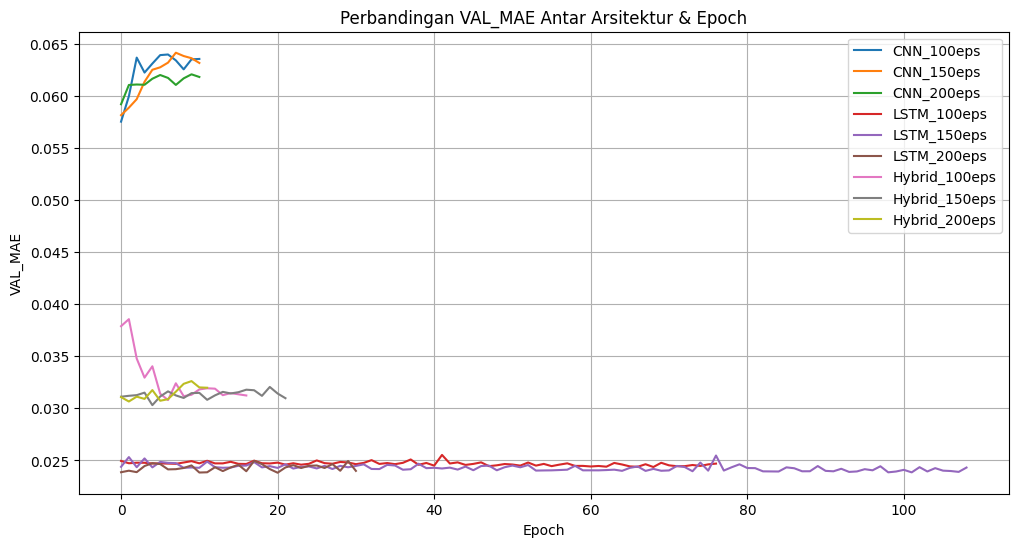

In [ ]:
import matplotlib.pyplot as plt

def plot_comparison(all_histories, metric='val_mae'):
    plt.figure(figsize=(12, 6))

    for label, history in all_histories.items():
        plt.plot(history.history[metric], label=label)

    plt.title(f'Perbandingan {metric.upper()} Antar Arsitektur & Epoch')
    plt.ylabel(metric.upper())
    plt.xlabel('Epoch')
    plt.legend()
    plt.grid(True)
    plt.show()

# Memanggil fungsi plot
plot_comparison(all_histories)